# Semana 05 · Visualización con Matplotlib y Seaborn
**Programación para la Inteligencia Artificial · MAPS**  
M. en C. Gabriela Martínez

## Propósito
Construir e interpretar visualizaciones a partir de un DataFrame. Retomaremos el caso IRIS de la Semana 04 para estudiar figuras, ejes, distribuciones, comparaciones y relaciones entre variables.

Al terminar podrás elegir una gráfica para una pregunta, personalizarla y explicar un hallazgo con sus límites.

## Forma de trabajo
1. Ejecuta las celdas en orden desde la preparación.
2. Lee la pregunta antes de ejecutar cada ejemplo y predice el resultado.
3. Completa los retos en las celdas marcadas con `TODO`. Al inicio solo contienen comentarios, por lo que no impiden ejecutar los ejemplos.
4. Escribe tus interpretaciones en las celdas de texto y guarda el notebook.

Usa Jupyter, VS Code con Jupyter o Google Colab. Si reinicias el kernel, vuelve a ejecutar las celdas anteriores. Los retos son independientes de los ejemplos posteriores: utiliza los nombres de variables sugeridos para conservar `df`.

**Entrega de práctica:** notebook con los retos completos, respuestas breves y las figuras del reto integrador. Consulta en Canvas las fechas y la rúbrica oficial.


## 0. Preparación del entorno
Se requieren `pandas`, `matplotlib` y `seaborn`. Si aparece `ModuleNotFoundError`, quita el primer `#` de la siguiente línea de instalación, ejecútala y reinicia el kernel si el entorno lo solicita. La instalación requiere internet.

El dataset completo está incluido en este notebook. Después de instalar las librerías, los ejercicios funcionan sin conexión.


In [ ]:
# %pip install "pandas>=2.2,<3" "matplotlib>=3.8,<4" "seaborn==0.13.2"


In [ ]:
from io import StringIO
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print('Pandas:', pd.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Seaborn:', sns.__version__)


Pandas: 2.2.3
Matplotlib: 3.10.0
Seaborn: 0.13.2


### Datos de trabajo
IRIS contiene 150 flores, 50 de cada especie. Cada fila representa una observación. Las columnas `sepal_length`, `sepal_width`, `petal_length` y `petal_width` son medidas en centímetros. `species` identifica la especie.

La siguiente celda contiene una copia completa del [CSV público de seaborn-data](https://github.com/mwaskom/seaborn-data/blob/master/iris.csv), consultado el 8 de septiembre de 2026. No usamos la muestra reducida de respaldo del notebook de Semana 04. No elimines duplicados automáticamente: medidas iguales pueden corresponder a flores distintas.


In [ ]:
IRIS_CSV = """sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa
4.9,3.1,1.5,0.1,setosa
5.4,3.7,1.5,0.2,setosa
4.8,3.4,1.6,0.2,setosa
4.8,3.0,1.4,0.1,setosa
4.3,3.0,1.1,0.1,setosa
5.8,4.0,1.2,0.2,setosa
5.7,4.4,1.5,0.4,setosa
5.4,3.9,1.3,0.4,setosa
5.1,3.5,1.4,0.3,setosa
5.7,3.8,1.7,0.3,setosa
5.1,3.8,1.5,0.3,setosa
5.4,3.4,1.7,0.2,setosa
5.1,3.7,1.5,0.4,setosa
4.6,3.6,1.0,0.2,setosa
5.1,3.3,1.7,0.5,setosa
4.8,3.4,1.9,0.2,setosa
5.0,3.0,1.6,0.2,setosa
5.0,3.4,1.6,0.4,setosa
5.2,3.5,1.5,0.2,setosa
5.2,3.4,1.4,0.2,setosa
4.7,3.2,1.6,0.2,setosa
4.8,3.1,1.6,0.2,setosa
5.4,3.4,1.5,0.4,setosa
5.2,4.1,1.5,0.1,setosa
5.5,4.2,1.4,0.2,setosa
4.9,3.1,1.5,0.2,setosa
5.0,3.2,1.2,0.2,setosa
5.5,3.5,1.3,0.2,setosa
4.9,3.6,1.4,0.1,setosa
4.4,3.0,1.3,0.2,setosa
5.1,3.4,1.5,0.2,setosa
5.0,3.5,1.3,0.3,setosa
4.5,2.3,1.3,0.3,setosa
4.4,3.2,1.3,0.2,setosa
5.0,3.5,1.6,0.6,setosa
5.1,3.8,1.9,0.4,setosa
4.8,3.0,1.4,0.3,setosa
5.1,3.8,1.6,0.2,setosa
4.6,3.2,1.4,0.2,setosa
5.3,3.7,1.5,0.2,setosa
5.0,3.3,1.4,0.2,setosa
7.0,3.2,4.7,1.4,versicolor
6.4,3.2,4.5,1.5,versicolor
6.9,3.1,4.9,1.5,versicolor
5.5,2.3,4.0,1.3,versicolor
6.5,2.8,4.6,1.5,versicolor
5.7,2.8,4.5,1.3,versicolor
6.3,3.3,4.7,1.6,versicolor
4.9,2.4,3.3,1.0,versicolor
6.6,2.9,4.6,1.3,versicolor
5.2,2.7,3.9,1.4,versicolor
5.0,2.0,3.5,1.0,versicolor
5.9,3.0,4.2,1.5,versicolor
6.0,2.2,4.0,1.0,versicolor
6.1,2.9,4.7,1.4,versicolor
5.6,2.9,3.6,1.3,versicolor
6.7,3.1,4.4,1.4,versicolor
5.6,3.0,4.5,1.5,versicolor
5.8,2.7,4.1,1.0,versicolor
6.2,2.2,4.5,1.5,versicolor
5.6,2.5,3.9,1.1,versicolor
5.9,3.2,4.8,1.8,versicolor
6.1,2.8,4.0,1.3,versicolor
6.3,2.5,4.9,1.5,versicolor
6.1,2.8,4.7,1.2,versicolor
6.4,2.9,4.3,1.3,versicolor
6.6,3.0,4.4,1.4,versicolor
6.8,2.8,4.8,1.4,versicolor
6.7,3.0,5.0,1.7,versicolor
6.0,2.9,4.5,1.5,versicolor
5.7,2.6,3.5,1.0,versicolor
5.5,2.4,3.8,1.1,versicolor
5.5,2.4,3.7,1.0,versicolor
5.8,2.7,3.9,1.2,versicolor
6.0,2.7,5.1,1.6,versicolor
5.4,3.0,4.5,1.5,versicolor
6.0,3.4,4.5,1.6,versicolor
6.7,3.1,4.7,1.5,versicolor
6.3,2.3,4.4,1.3,versicolor
5.6,3.0,4.1,1.3,versicolor
5.5,2.5,4.0,1.3,versicolor
5.5,2.6,4.4,1.2,versicolor
6.1,3.0,4.6,1.4,versicolor
5.8,2.6,4.0,1.2,versicolor
5.0,2.3,3.3,1.0,versicolor
5.6,2.7,4.2,1.3,versicolor
5.7,3.0,4.2,1.2,versicolor
5.7,2.9,4.2,1.3,versicolor
6.2,2.9,4.3,1.3,versicolor
5.1,2.5,3.0,1.1,versicolor
5.7,2.8,4.1,1.3,versicolor
6.3,3.3,6.0,2.5,virginica
5.8,2.7,5.1,1.9,virginica
7.1,3.0,5.9,2.1,virginica
6.3,2.9,5.6,1.8,virginica
6.5,3.0,5.8,2.2,virginica
7.6,3.0,6.6,2.1,virginica
4.9,2.5,4.5,1.7,virginica
7.3,2.9,6.3,1.8,virginica
6.7,2.5,5.8,1.8,virginica
7.2,3.6,6.1,2.5,virginica
6.5,3.2,5.1,2.0,virginica
6.4,2.7,5.3,1.9,virginica
6.8,3.0,5.5,2.1,virginica
5.7,2.5,5.0,2.0,virginica
5.8,2.8,5.1,2.4,virginica
6.4,3.2,5.3,2.3,virginica
6.5,3.0,5.5,1.8,virginica
7.7,3.8,6.7,2.2,virginica
7.7,2.6,6.9,2.3,virginica
6.0,2.2,5.0,1.5,virginica
6.9,3.2,5.7,2.3,virginica
5.6,2.8,4.9,2.0,virginica
7.7,2.8,6.7,2.0,virginica
6.3,2.7,4.9,1.8,virginica
6.7,3.3,5.7,2.1,virginica
7.2,3.2,6.0,1.8,virginica
6.2,2.8,4.8,1.8,virginica
6.1,3.0,4.9,1.8,virginica
6.4,2.8,5.6,2.1,virginica
7.2,3.0,5.8,1.6,virginica
7.4,2.8,6.1,1.9,virginica
7.9,3.8,6.4,2.0,virginica
6.4,2.8,5.6,2.2,virginica
6.3,2.8,5.1,1.5,virginica
6.1,2.6,5.6,1.4,virginica
7.7,3.0,6.1,2.3,virginica
6.3,3.4,5.6,2.4,virginica
6.4,3.1,5.5,1.8,virginica
6.0,3.0,4.8,1.8,virginica
6.9,3.1,5.4,2.1,virginica
6.7,3.1,5.6,2.4,virginica
6.9,3.1,5.1,2.3,virginica
5.8,2.7,5.1,1.9,virginica
6.8,3.2,5.9,2.3,virginica
6.7,3.3,5.7,2.5,virginica
6.7,3.0,5.2,2.3,virginica
6.3,2.5,5.0,1.9,virginica
6.5,3.0,5.2,2.0,virginica
6.2,3.4,5.4,2.3,virginica
5.9,3.0,5.1,1.8,virginica
"""

df = pd.read_csv(StringIO(IRIS_CSV))
medidas = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
especies = ["setosa", "versicolor", "virginica"]
paleta = dict(zip(especies, sns.color_palette("colorblind", 3)))

assert df.shape == (150, 5)
assert df[medidas + ["species"]].notna().all().all()
print("Dimensiones:", df.shape)
display(df.head())
display(df["species"].value_counts())


Dimensiones: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,count
species,
setosa,50
versicolor,50
virginica,50


## 1. Repaso de Pandas: lectura y análisis de código
Antes de ejecutar, responde:
- ¿Qué representa una fila de `df`?
- ¿Qué diferencia hay entre filtrar registros y agruparlos?
- ¿La media por especie describe toda la variabilidad?

**Mis respuestas iniciales:** _Escribe aquí._

Lee el código: `filtro` conserva observaciones que cumplen una condición. `resumen` obtiene estadísticas por especie. `count` cuenta valores no nulos, `mean` calcula la media y `std` la desviación estándar muestral. `display()` muestra explícitamente cada resultado.


In [ ]:
display(df.head())
filtro = df.loc[df['petal_length'] > 5, ['species', 'petal_length']]
resumen = (df.groupby('species')['petal_length']
             .agg(['count', 'mean', 'std']).round(2))
print('Primeras filas del filtro:')
display(filtro.head())
print('Resumen de todas las flores:')
display(resumen)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Primeras filas del filtro:


,species,petal_length
83,versicolor,5.1
100,virginica,6.0
101,virginica,5.1
102,virginica,5.9
103,virginica,5.6


Resumen de todas las flores:


,count,mean,std
species,,,
setosa,50,1.46,0.17
versicolor,50,4.26,0.47
virginica,50,5.55,0.55


# Tema 9. Visualización con Matplotlib
## 2. Figure, Axes y gráfica de dispersión
**Pregunta:** ¿cómo se relacionan la longitud y el ancho del pétalo?

`Figure` contiene la composición. `Axes` es el área de trazado y administra título, etiquetas y datos. `Axis` es cada eje de coordenadas con sus marcas y escala.

`plt.subplots()` crea `fig` y `ax`. `scatter()` dibuja una observación por punto. `alpha` controla la transparencia y `s` el área de los marcadores. La superposición puede ocultar flores con medidas iguales.


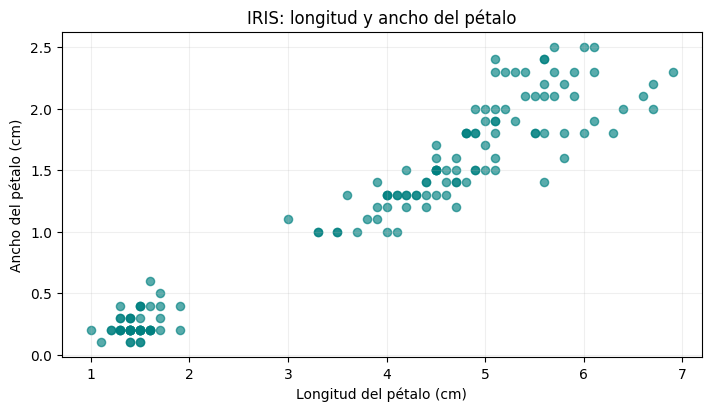

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
ax.scatter(df['petal_length'], df['petal_width'],
           alpha=0.65, s=35, color='teal')
ax.set(title='IRIS: longitud y ancho del pétalo',
       xlabel='Longitud del pétalo (cm)', ylabel='Ancho del pétalo (cm)')
ax.grid(alpha=0.2)
plt.show()


### Reto 2 · Cambiar las variables

Crea otra dispersión usando longitud y ancho del sépalo. Actualiza título y unidades. Prueba `alpha=0.3` y `alpha=1`.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea fig_reto2, ax_reto2 con plt.subplots().
# TODO: usa sepal_length y sepal_width en scatter().
# TODO: actualiza título, etiquetas y transparencia.
# TODO: muestra la figura con plt.show().


**Interpretación del reto**

¿La relación del sépalo parece tan clara como la del pétalo? ¿Cómo influye la transparencia en la lectura?

**Mi respuesta:** _Escribe aquí._


## 3. Barras: comparación de categorías
**Pregunta:** ¿cuál es la longitud media del pétalo en cada especie?

Primero calculamos una media por especie con Pandas. Luego Matplotlib representa esas medias. Las barras comienzan en cero para que sus longitudes permitan comparar magnitudes. Una barra de medias no muestra la dispersión interna.


,petal_length
species,
setosa,1.462
versicolor,4.260
virginica,5.552


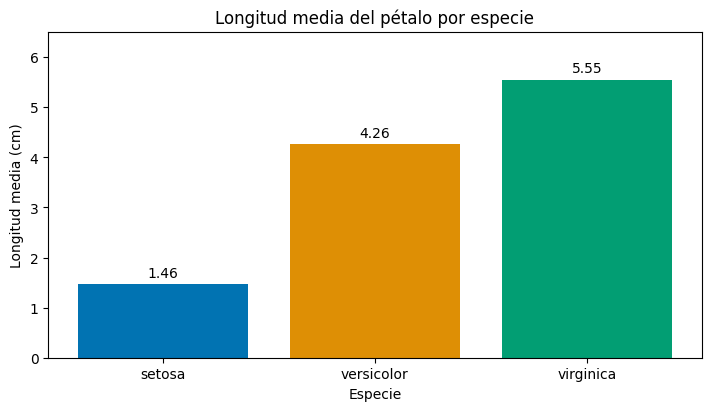

In [ ]:
medias = df.groupby('species')['petal_length'].mean().reindex(especies)
display(medias.round(3))
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
barras = ax.bar(medias.index, medias.values,
                color=[paleta[e] for e in especies])
ax.bar_label(barras, fmt='%.2f', padding=3)
ax.set(title='Longitud media del pétalo por especie',
       xlabel='Especie', ylabel='Longitud media (cm)', ylim=(0, 6.5))
plt.show()


### Reto 3 · Otra medida por especie

Calcula `medias_reto3` para `sepal_width` y crea una gráfica de barras. Conserva el orden de especies y el inicio del eje Y en cero.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: calcula las medias de sepal_width por species.
# TODO: crea la figura y las barras usando medias_reto3.
# TODO: ajusta título, etiquetas y límite inferior del eje Y.
# TODO: muestra la figura.


**Interpretación del reto**

¿La especie con mayor ancho medio de sépalo también tiene el pétalo más largo en promedio?

**Mi respuesta:** _Escribe aquí._


## 4. Histogramas: distribución de una variable
**Pregunta:** ¿en qué intervalos se concentran las longitudes de pétalo?

El histograma agrupa medidas en intervalos (`bins`) y cuenta observaciones. Cambiar los intervalos puede hacer visibles u ocultar detalles. Sus barras representan intervalos numéricos, mientras que las barras de la sección anterior representan especies.


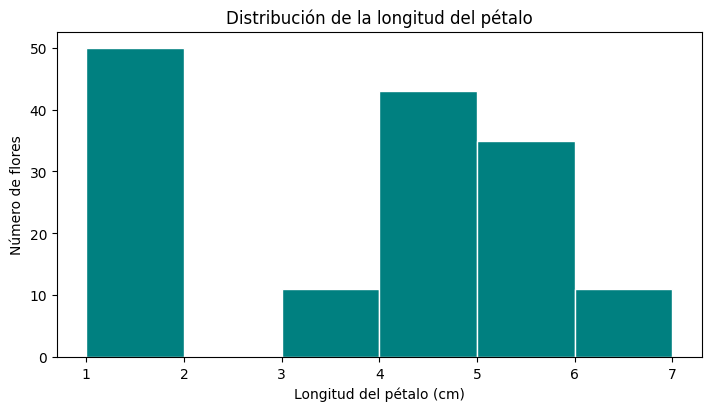

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
ax.hist(df['petal_length'], bins=[1, 2, 3, 4, 5, 6, 7],
        color='teal', edgecolor='white')
ax.set(title='Distribución de la longitud del pétalo',
       xlabel='Longitud del pétalo (cm)', ylabel='Número de flores')
plt.show()


### Reto 4 · El efecto de bins

Grafica `petal_length` primero con `bins=5` y después con `bins=15`. Usa el mismo rango horizontal, de 1 a 7 cm.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea una figura para cada valor de bins.
# TODO: conserva datos, etiquetas y xlim=(1, 7).
# TODO: compara las dos gráficas.


**Interpretación del reto**

¿Qué detalle cambia? ¿Qué patrón permanece? ¿Por qué no conviene concluir a partir de una sola elección de bins?

**Mi respuesta:** _Escribe aquí._


## 5. Subplots: comparación en una figura
**Pregunta:** ¿cómo cambia la distribución del pétalo entre especies?

`plt.subplots(1, 3)` devuelve tres Axes. El ciclo asigna una especie a cada panel. Compartimos escalas y límites de bins para facilitar la comparación.


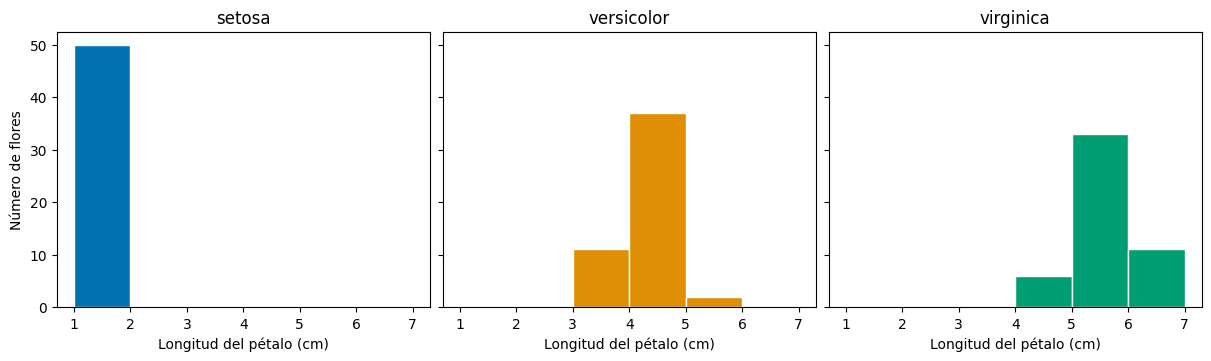

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True,
                        sharey=True, layout='constrained')
for ax, especie in zip(axs, especies):
    valores = df.loc[df['species'] == especie, 'petal_length']
    ax.hist(valores, bins=[1, 2, 3, 4, 5, 6, 7],
            color=paleta[especie], edgecolor='white')
    ax.set(title=especie, xlabel='Longitud del pétalo (cm)')
axs[0].set_ylabel('Número de flores')
plt.show()


### Reto 5 · Comparación del sépalo

Adapta los tres paneles a `sepal_length`. Usa los mismos bins para todas las especies: `[4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8]`.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea tres paneles con ejes compartidos.
# TODO: filtra cada especie y grafica sepal_length con los bins indicados.
# TODO: cambia las etiquetas y muestra la figura.


**Interpretación del reto**

¿Por qué usar intervalos o escalas diferentes dificultaría comparar las distribuciones?

**Mi respuesta:** _Escribe aquí._


## 6. Líneas: datos con un orden significativo
**Pregunta:** ¿cómo cambia una pérdida a lo largo del entrenamiento?

Una línea conecta observaciones en un orden real. Este ejemplo usa datos **simulados con fines didácticos**. El índice de fila de IRIS no representa tiempo: unir sus flores podría sugerir una tendencia artificial.


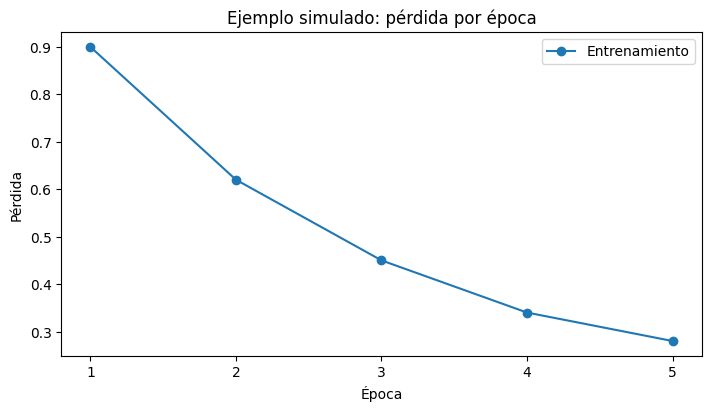

In [ ]:
epocas = [1, 2, 3, 4, 5]
perdida_entrenamiento = [0.90, 0.62, 0.45, 0.34, 0.28]
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
ax.plot(epocas, perdida_entrenamiento, marker='o', label='Entrenamiento')
ax.set(title='Ejemplo simulado: pérdida por época',
       xlabel='Época', ylabel='Pérdida', xticks=epocas)
ax.legend()
plt.show()


### Reto 6 · Agregar una segunda serie

Agrega la pérdida de validación `[0.95, 0.70, 0.58, 0.60, 0.66]` en la misma figura. Usa una línea distinta y una leyenda.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
perdida_validacion = [0.95, 0.70, 0.58, 0.60, 0.66]
# TODO: crea una nueva figura y grafica ambas series contra epocas.
# TODO: agrega etiquetas, leyenda y un título que indique datos simulados.


**Interpretación del reto**

¿A partir de qué época las curvas evolucionan en sentidos distintos? Describe el patrón sin afirmar que estos valores pertenecen a un modelo real.

**Mi respuesta:** _Escribe aquí._


## 7. Personalización y exportación
**Pregunta:** ¿cómo guardar una figura que otra persona pueda interpretar?

La anotación debe señalar un valor calculado. `figsize` se expresa en pulgadas. En PNG, `dpi` controla la resolución. Guardamos antes de `plt.show()` y usamos `bbox_inches='tight'` para incluir los elementos exteriores.

Esta celda crea `salidas_semana05` en el directorio de trabajo. Al volver a ejecutarla, actualiza el archivo del mismo nombre. En Colab puedes descargarlo desde el panel Archivos.


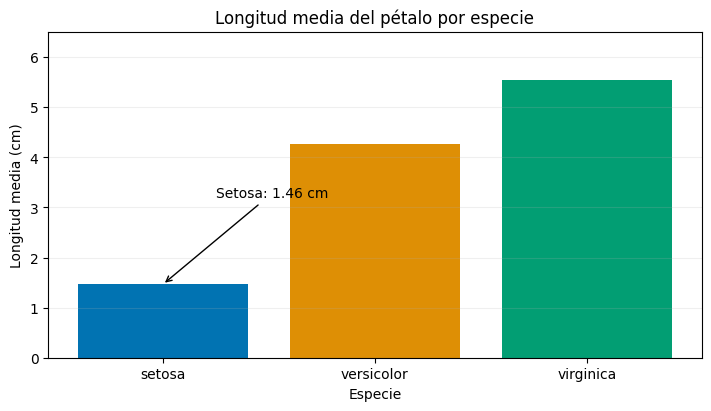

Archivo guardado: /content/salidas_semana05/matplotlib_medias_petalo.png


In [ ]:
carpeta_salida = Path('salidas_semana05')
carpeta_salida.mkdir(exist_ok=True)
medias = df.groupby('species')['petal_length'].mean().reindex(especies)
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
ax.bar(medias.index, medias.values, color=[paleta[e] for e in especies])
ax.set(title='Longitud media del pétalo por especie',
       xlabel='Especie', ylabel='Longitud media (cm)', ylim=(0, 6.5))
ax.annotate(f"Setosa: {medias.loc['setosa']:.2f} cm",
            xy=(0, medias.loc['setosa']), xytext=(0.25, 3.2),
            arrowprops={'arrowstyle': '->'})
ax.grid(axis='y', alpha=0.2)
ruta = carpeta_salida / 'matplotlib_medias_petalo.png'
fig.savefig(ruta, dpi=200, bbox_inches='tight')
plt.show()
print('Archivo guardado:', ruta.resolve())


### Reto 7 · Anotar y guardar

Crea una figura de barras nueva, anota la media de `virginica` y guarda `reto7_virginica.png` en `carpeta_salida`. Obtén el valor desde `medias`.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea fig_reto7 y ax_reto7 y dibuja las medias.
# TODO: anota virginica usando su posición 2 y medias.loc['virginica'].
# TODO: añade título y etiquetas.
# TODO: guarda antes de mostrar y comprueba la ruta con .exists().


**Interpretación del reto**

¿Por qué es preferible calcular el valor de la anotación en lugar de escribirlo manualmente?

**Mi respuesta:** _Escribe aquí._


# Tema 10. Visualización estadística con Seaborn
## 8. Variables y grupos: data, x, y, hue y style
**Pregunta:** ¿la relación del pétalo cambia al identificar las especies?

Seaborn usa Matplotlib. `data` recibe el DataFrame y `x`, `y` los nombres de columnas. `hue` distingue especies por color y `style` por marcador. La paleta mantiene los colores de los ejemplos anteriores. `ax=` permite dibujar en un Axes que ya creamos.


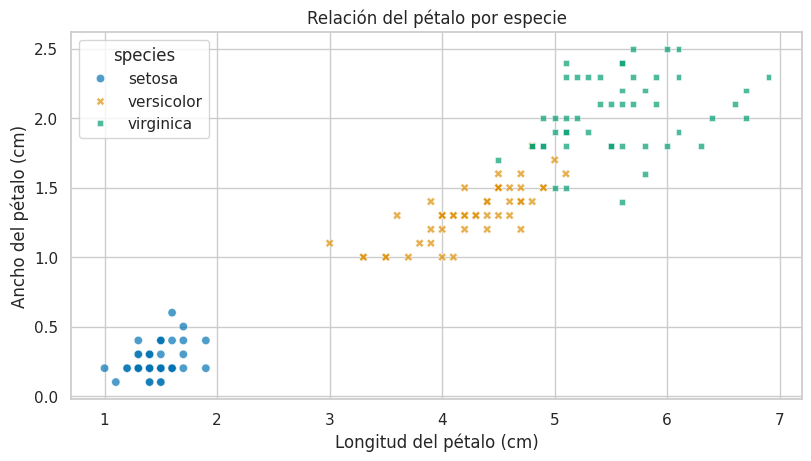

In [ ]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', style='species', hue_order=especies,
                palette=paleta, alpha=0.7, ax=ax)
ax.set(title='Relación del pétalo por especie',
       xlabel='Longitud del pétalo (cm)', ylabel='Ancho del pétalo (cm)')
plt.show()


### Reto 8 · Separación y solapamiento

Repite la dispersión con `sepal_length` y `sepal_width`. Conserva `hue` y `style` por especie.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea una figura y llama sns.scatterplot con medidas del sépalo.
# TODO: conserva palette=paleta y etiquetas con unidades.
# TODO: muestra la figura.


**Interpretación del reto**

¿Qué par de medidas permite distinguir mejor setosa en estas gráficas? ¿Por qué esto no demuestra la precisión de un clasificador?

**Mi respuesta:** _Escribe aquí._


## 9. Histograma y densidad con Seaborn
**Pregunta:** ¿dónde se concentran los valores de cada especie?

La izquierda muestra conteos. La derecha estima densidades con KDE. `bw_adjust` cambia el suavizado. Usamos `common_norm=False` para que la densidad de cada especie tenga área 1. La altura de la densidad no es el número de flores ni una probabilidad puntual. `cut=0` limita la curva al rango observado, pero no elimina todos los sesgos de estimación.


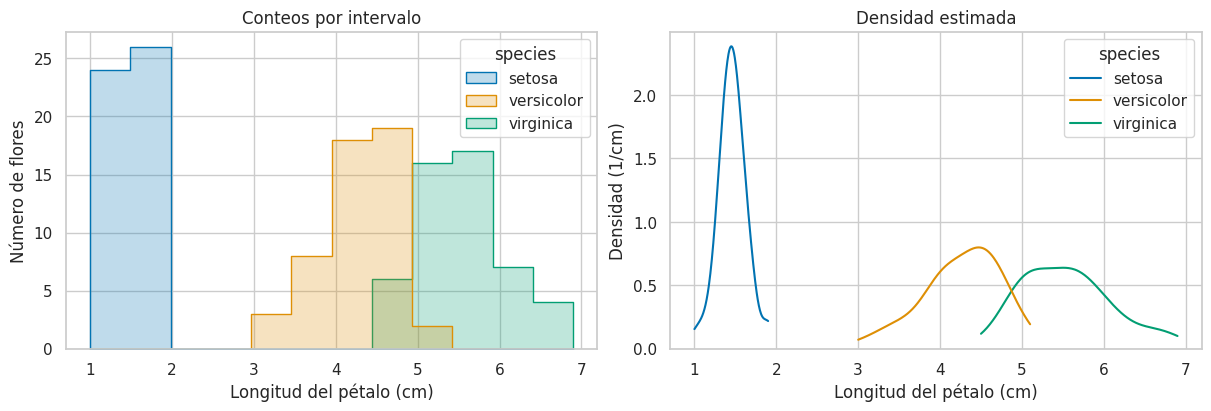

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
sns.histplot(data=df, x='petal_length', hue='species', palette=paleta,
             binwidth=0.5, element='step', stat='count', ax=axs[0])
sns.kdeplot(data=df, x='petal_length', hue='species', palette=paleta,
            bw_adjust=1, common_norm=False, cut=0, ax=axs[1])
axs[0].set(title='Conteos por intervalo', xlabel='Longitud del pétalo (cm)',
           ylabel='Número de flores')
axs[1].set(title='Densidad estimada', xlabel='Longitud del pétalo (cm)',
           ylabel='Densidad (1/cm)')
plt.show()


### Reto 9 · Suavizado

Crea dos KDE con `bw_adjust=0.5` y `bw_adjust=2`. Conserva los datos, la paleta y `common_norm=False`.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea dos paneles y repite sns.kdeplot con cada bw_adjust.
# TODO: indica el valor de suavizado en cada título.
# TODO: agrega etiquetas y muestra las figuras.


**Interpretación del reto**

¿Cuál curva muestra más detalle? ¿Qué riesgo tiene interpretar cada pequeño pico como un grupo real?

**Mi respuesta:** _Escribe aquí._


## 10. Boxplot: variabilidad por especie
**Pregunta:** ¿qué diferencias oculta la barra de medias?

La línea central de la caja indica la mediana. La caja abarca Q1 a Q3 y su altura es el rango intercuartílico (IQR). Con `whis=1.5`, los bigotes llegan al dato extremo dentro de Q1 − 1.5 IQR y Q3 + 1.5 IQR. Un punto fuera de los bigotes es una señal para revisar, no una orden para eliminarlo.

Superponemos observaciones con `stripplot`. `jitter` separa horizontalmente puntos para facilitar su lectura; esa separación no representa otra variable. Su posición horizontal puede variar ligeramente al repetir la celda.


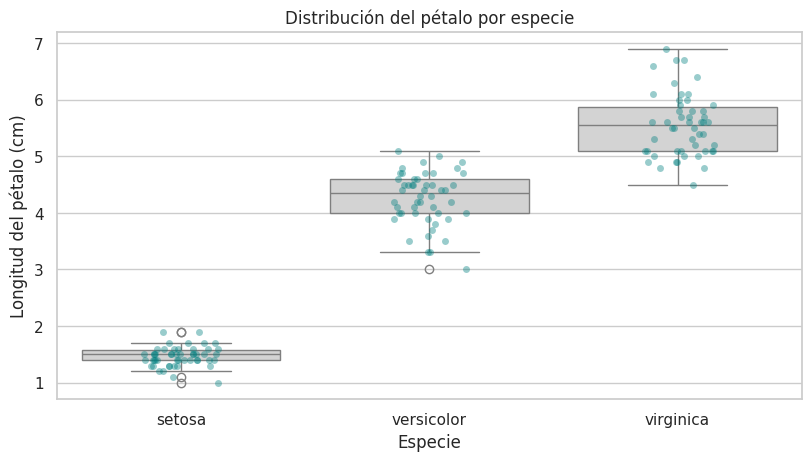

,0.25,0.50,0.75
species,,,
setosa,1.4,1.50,1.575
versicolor,4.0,4.35,4.600
virginica,5.1,5.55,5.875


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
sns.boxplot(data=df, x='species', y='petal_length', order=especies,
            whis=1.5, color='lightgray', ax=ax)
sns.stripplot(data=df, x='species', y='petal_length', order=especies,
              color='teal', alpha=0.4, jitter=0.15, ax=ax)
ax.set(title='Distribución del pétalo por especie',
       xlabel='Especie', ylabel='Longitud del pétalo (cm)')
plt.show()
display(df.groupby('species')['petal_length'].quantile([0.25, 0.5, 0.75]).unstack())


### Reto 10 · Mediana e IQR

Cambia la medida a `sepal_width`. Calcula sus cuartiles por especie y agrega una columna `IQR = Q3 - Q1`.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea el boxplot de sepal_width por especie.
# TODO: calcula cuartiles_reto10 con quantile([0.25, 0.5, 0.75]).unstack().
# TODO: resta las columnas 0.75 y 0.25 para obtener IQR y muestra la tabla.


**Interpretación del reto**

¿Qué especie tiene mayor IQR? Si hay empate, indícalo. ¿La mediana más alta implica necesariamente mayor dispersión?

**Mi respuesta:** _Escribe aquí._


## 11. Heatmap de correlaciones
**Pregunta:** ¿qué pares de medidas presentan asociación lineal?

Pearson toma valores de −1 a 1. Un valor próximo a 0 no descarta una relación no lineal. Seleccionamos medidas numéricas; no convertimos la especie a números para tratarla como una magnitud. `vmin`, `vmax` y `center` mantienen una escala comparable. Correlación no implica causalidad.


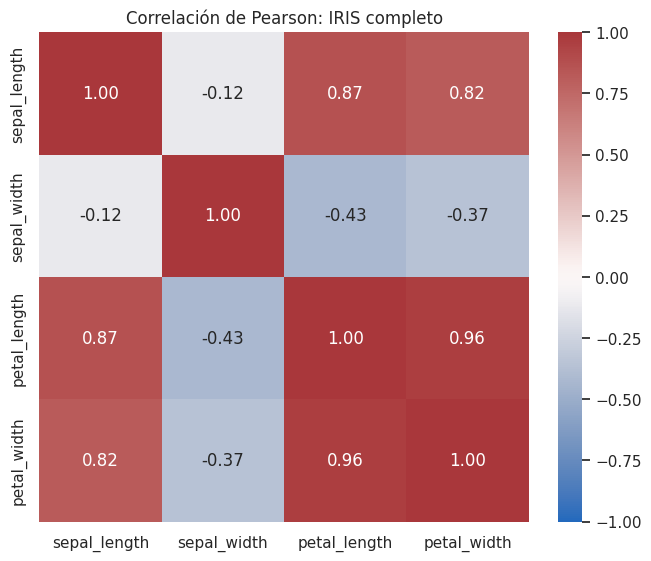

In [ ]:
corr = df[medidas].corr(method='pearson')
fig, ax = plt.subplots(figsize=(7, 5.5), layout='constrained')
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            center=0, cmap='vlag', square=True, ax=ax)
ax.set_title('Correlación de Pearson: IRIS completo')
plt.show()


### Reto 11 · Correlación dentro de un grupo

Filtra `setosa` y calcula `corr_setosa` usando las mismas cuatro medidas. Dibuja otro heatmap con escala de −1 a 1.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: filtra setosa en df_setosa.
# TODO: calcula corr_setosa = df_setosa[medidas].corr().
# TODO: dibuja el heatmap conservando vmin, vmax, center y cmap.


**Interpretación del reto**

Compara la correlación entre longitud y ancho del pétalo en ambos mapas. ¿Por qué una relación global puede cambiar al separar grupos?

**Mi respuesta:** _Escribe aquí._


## 12. Pairplot: exploración de varios pares
**Pregunta:** ¿qué pares vale la pena estudiar con más detalle?

Fuera de la diagonal aparecen dispersiones y en la diagonal histogramas. `corner=True` omite pares repetidos. `pairplot` crea su propia cuadrícula y devuelve un `PairGrid`, por lo que no recibe `ax=`. `g.savefig()` guarda la cuadrícula completa.


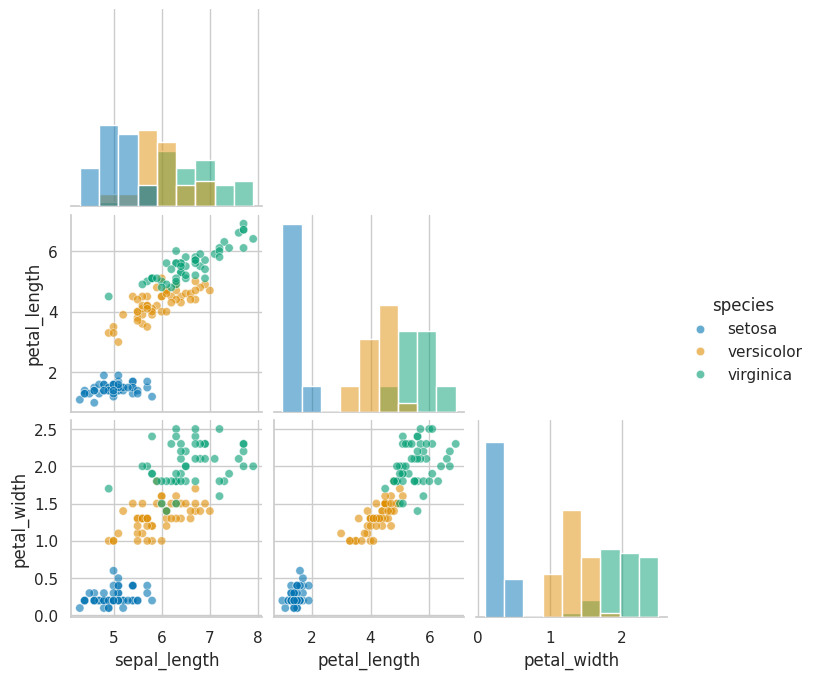

In [ ]:
g = sns.pairplot(df, vars=['sepal_length', 'petal_length', 'petal_width'],
                 hue='species', hue_order=especies, palette=paleta,
                 diag_kind='hist', corner=True, height=2.3,
                 plot_kws={'alpha': 0.6})
g.savefig(carpeta_salida / 'seaborn_pairplot_iris.png', dpi=160)
plt.show()


### Reto 12 · Selección de variables

Crea `g_reto12` con las cuatro columnas de `medidas`. Elige un par que quieras ampliar después en una dispersión individual.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: llama sns.pairplot con vars=medidas y corner=True.
# TODO: conserva hue='species' y diag_kind='hist'.
# TODO: muestra la cuadrícula.


**Interpretación del reto**

¿Qué par elegiste y qué pregunta responderías con él? ¿Qué problema de lectura tendrías al incluir decenas de variables?

**Mi respuesta:** _Escribe aquí._


## 13. Comparación justa: Matplotlib y Seaborn
**Pregunta:** ¿ambas bibliotecas producen el mismo resumen?

`ax.bar` recibe medias ya calculadas. `sns.barplot` calcula un estimador, la media por defecto. Usamos `errorbar=None` para comparar únicamente las mismas medias. `countplot`, en cambio, cuenta registros. Las barras de error predeterminadas de `barplot` representan intervalos de confianza, no la dispersión de todas las flores.


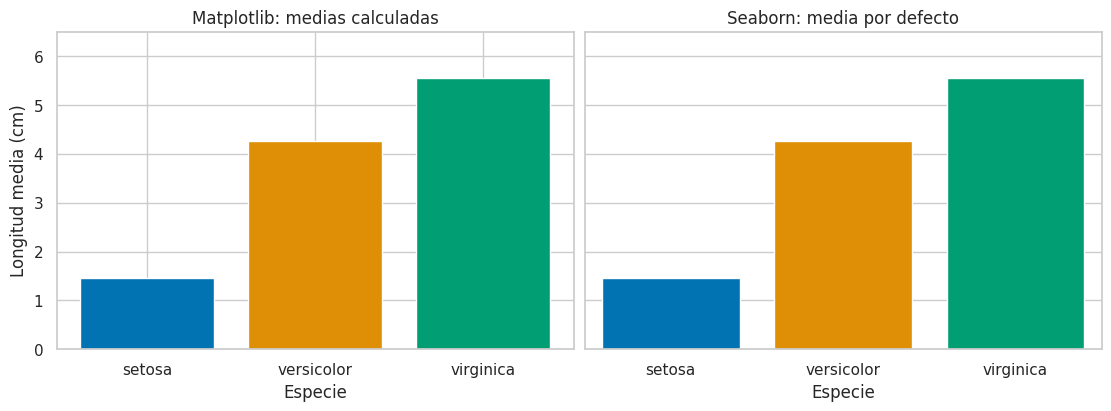

In [ ]:
medias = df.groupby('species')['petal_length'].mean().reindex(especies)
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True,
                        layout='constrained')
axs[0].bar(especies, medias.values, color=[paleta[e] for e in especies])
sns.barplot(data=df, x='species', y='petal_length', order=especies,
            hue='species', hue_order=especies, palette=paleta,
            legend=False, errorbar=None, saturation=1, ax=axs[1])
for ax, titulo in zip(axs, ['Matplotlib: medias calculadas', 'Seaborn: media por defecto']):
    ax.set(title=titulo, xlabel='Especie', ylabel='Longitud media (cm)', ylim=(0, 6.5))
plt.show()


### Reto 13 · Conteo frente a promedio

Crea `sns.countplot(data=df, x="species", order=especies)`. Compara el significado de sus alturas con las barras anteriores.

Trabaja en la siguiente celda. Los comentarios son una guía para completar el ejercicio.


In [ ]:
# TODO: crea fig_reto13, ax_reto13.
# TODO: dibuja countplot y etiqueta el eje Y como Número de flores.
# TODO: muestra la gráfica y contrasta con df['species'].value_counts().


**Interpretación del reto**

¿Por qué las tres barras de conteos tienen la misma altura, aunque las medias de pétalo sean distintas?

**Mi respuesta:** _Escribe aquí._


## 14. Reto integrador: una pregunta y dos vistas
Elige una pregunta sobre **las medidas del sépalo** para aplicar el proceso sin copiar los ejemplos del pétalo.

1. Escribe la pregunta e identifica las variables.
2. Verifica el tamaño del dataset y los nulos de esas columnas.
3. Crea una gráfica con Matplotlib y otra con Seaborn que respondan la pregunta o aporten vistas complementarias.
4. Incluye título, unidades, leyenda cuando corresponda y escalas comparables.
5. Guarda las figuras como `reto_final_matplotlib.png` y `reto_final_seaborn.png` en `carpeta_salida`.
6. Explica un hallazgo y una limitación. Distingue observación de explicación causal.

**Mi pregunta:** _Escribe aquí._  
**Variables y gráficas elegidas:** _Escribe aquí._


In [ ]:
# TODO: revisa los datos relevantes para tu pregunta.
# TODO: crea y guarda la figura de Matplotlib.
# TODO: crea y guarda la figura de Seaborn.
# TODO: muestra ambas figuras.


### Cierre y autoevaluación
**Hallazgo:** _Escribe una afirmación apoyada en tus figuras._  
**Evidencia:** _Indica qué valores, grupos o patrones la apoyan._  
**Limitación:** _Explica qué no puedes concluir con estos datos o gráficas._

- [ ] Puedo explicar qué representa una fila, un punto y una barra en mis resultados.
- [ ] Diferencio filtro, agrupación, conteo y promedio.
- [ ] Mis etiquetas identifican variables y unidades.
- [ ] Puedo explicar el efecto de bins, suavizado y agrupación por especie.
- [ ] Mis figuras están guardadas y puedo localizar los archivos.
- [ ] Los ejemplos y mis retos se ejecutan en orden después de reiniciar el kernel.

## Fuentes de consulta
- [Matplotlib: guía de inicio](https://matplotlib.org/stable/users/explain/quick_start.html)
- [Matplotlib: guardar figuras](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html)
- [Seaborn: tipos de funciones](https://seaborn.pydata.org/tutorial/function_overview.html)
- [Seaborn: distribuciones](https://seaborn.pydata.org/tutorial/distributions.html)
- [Seaborn: datos categóricos](https://seaborn.pydata.org/tutorial/categorical.html)
- [Seaborn: heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- [Seaborn: pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
- [Dataset IRIS de seaborn-data](https://github.com/mwaskom/seaborn-data/blob/master/iris.csv)

Material previo: `Semana_04_IRIS_Pandas_basico_avanzado.ipynb`.
